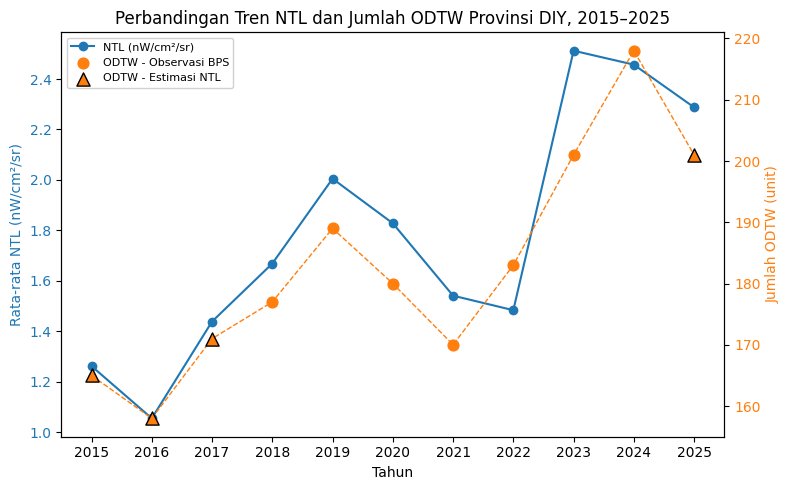

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ntl = pd.read_csv("/content/drive/MyDrive/Skripsi_Citra/NTL/NTL_DIY_2015_2025.csv")          # kolom: tahun, ntl_mean, ntl_sum
odtw = pd.read_csv("/content/drive/MyDrive/Skripsi_Citra/Estimasi ODTW menggunakan NTL/ODTW_DIY_2015_2025_Final.csv")      # kolom: tahun, jumlah_odtw, status

df = pd.merge(ntl[["tahun", "ntl_mean"]], odtw, on="tahun")

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(df["tahun"], df["ntl_mean"], color="tab:blue", marker="o", label="NTL (nW/cm²/sr)")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Rata-rata NTL (nW/cm²/sr)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(df["tahun"])

ax2 = ax1.twinx()
obs = df[df["status"] == "Observasi BPS"]
est = df[df["status"] == "Estimasi NTL"]

ax2.plot(df["tahun"], df["jumlah_odtw"], color="tab:orange", linestyle="--", linewidth=1, zorder=1)
ax2.scatter(obs["tahun"], obs["jumlah_odtw"], color="tab:orange", marker="o", s=60,
            label="ODTW - Observasi BPS", zorder=3)
ax2.scatter(est["tahun"], est["jumlah_odtw"], color="tab:orange", marker="^", s=90,
            edgecolor="black", label="ODTW - Estimasi NTL", zorder=3)

ax2.set_ylabel("Jumlah ODTW (unit)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8, framealpha=0.9)

plt.title("Perbandingan Tren NTL dan Jumlah ODTW Provinsi DIY, 2015–2025")
fig.tight_layout()
plt.savefig("Gambar_Validasi_Temporal_NTL_ODTW.png", dpi=300)
plt.show()

In [2]:
import os
import shutil

source_path = "/content/Gambar_Validasi_Temporal_NTL_ODTW.png"
destination_dir = "/content/drive/MyDrive/Skripsi_Citra/Estimasi ODTW menggunakan NTL"
destination_path = os.path.join(destination_dir, os.path.basename(source_path))

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Move the file
if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print(f"File moved successfully from {source_path} to {destination_path}")
else:
    print(f"Source file not found: {source_path}")

File moved successfully from /content/Gambar_Validasi_Temporal_NTL_ODTW.png to /content/drive/MyDrive/Skripsi_Citra/Estimasi ODTW menggunakan NTL/Gambar_Validasi_Temporal_NTL_ODTW.png
